# Normal toy example using SBI

In [1]:
import torch
import numpy as np
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.utils.torchutils import BoxUniform
from scipy.stats import norm, uniform
import matplotlib.pyplot as plt
import seaborn as sns


torch_device = "cpu"
torch.set_default_device(torch_device)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
prior_torch = BoxUniform(
    low=torch.tensor([0.0, 10.0], device=torch_device),
    high=torch.tensor([10.0, 1000.0], device=torch_device),
    device=torch_device
)

In [3]:
def simulator_torch_1(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s1 = torch.tensor([torch.mean(x)], device=torch_device)
    return s1

In [4]:
def simulator_torch_2(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s2 = torch.tensor([torch.mean(x), theta[1]], device=torch_device)
    return s2

In [5]:
def simulator_torch_3(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s3 = torch.tensor([torch.mean(x), torch.mean(x**2)], device=torch_device)
    return s3

In [6]:
def simulator_torch_4(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s4 = torch.tensor([torch.mean(x), torch.mean(x**2), theta[1]], device=torch_device)
    return s4

In [7]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([3.0, 100.0], device=torch_device)
x_o_4 = simulator_torch_4(true_theta)
x_o_1 = x_o_4[0]
x_o_2 = x_o_4[[0, 2]]
x_o_3 = x_o_4[[0, 1]]
true_theta, x_o_1, x_o_2, x_o_3, x_o_4

(tensor([  3., 100.]),
 tensor(2.7973),
 tensor([  2.7973, 100.0000]),
 tensor([2.7973, 8.7726]),
 tensor([  2.7973,   8.7726, 100.0000]))

In [8]:
def nrom_example_npe_c(
    simulation_budget, seed, prior, x_obs, simulator, num_posterior_samples=1000
):
    prior, num_parameters, prior_returns_numpy = process_prior(prior)
    simulator = process_simulator(simulator, prior, prior_returns_numpy)
    check_sbi_inputs(simulator, prior)

    inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

    learning_rate = 0.0005  # default value

    torch.manual_seed(seed)
    np.random.seed(seed)

    theta, x = simulate_for_sbi(
        simulator=simulator, proposal=prior, num_simulations=simulation_budget
    )

    density_estimator = inference.append_simulations(theta, x).train(
        max_num_epochs=100, learning_rate=learning_rate
    )
    posterior = inference.build_posterior(density_estimator).set_default_x(x_obs)

    theta_trained = posterior.sample((num_posterior_samples,), x=x_obs)
    theta_trained = theta_trained.reshape((num_posterior_samples, 2))

    return theta_trained.cpu().numpy()

In [9]:
posterior_1 = nrom_example_npe_c(5000, 1, prior_torch, x_o_1, simulator_torch_1)

100%|██████████| 5000/5000 [00:00<00:00, 27225.84it/s]


 Neural network successfully converged after 98 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\torch\utils\_device.py:106: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  return func(*args, **kwargs)
1090it [00:00, 29702.00it/s]            


In [10]:
posterior_2 = nrom_example_npe_c(5000, 1, prior_torch, x_o_2, simulator_torch_2)

100%|██████████| 5000/5000 [00:00<00:00, 26597.10it/s]


 Training neural network. Epochs trained: 101

1094it [00:00, 31783.17it/s]            


In [11]:
posterior_3 = nrom_example_npe_c(5000, 1, prior_torch, x_o_3, simulator_torch_3)

100%|██████████| 5000/5000 [00:00<00:00, 19100.27it/s]


 Neural network successfully converged after 92 epochs.

1092it [00:00, 47455.63it/s]            


In [12]:
posterior_4 = nrom_example_npe_c(5000, 1, prior_torch, x_o_4, simulator_torch_4)

100%|██████████| 5000/5000 [00:00<00:00, 17103.23it/s]


 Training neural network. Epochs trained: 101

1096it [00:00, 31575.76it/s]            


In [17]:
x_o_2

tensor([  2.7973, 100.0000])

In [18]:
prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_2_numpy = x_o_2.cpu().numpy()

prior = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

likelihood = norm.pdf(x_o_2_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_2_numpy[1]))

unnormalized_posterior = likelihood * prior
d_theta = theta_grid[1] - theta_grid[0]
posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)

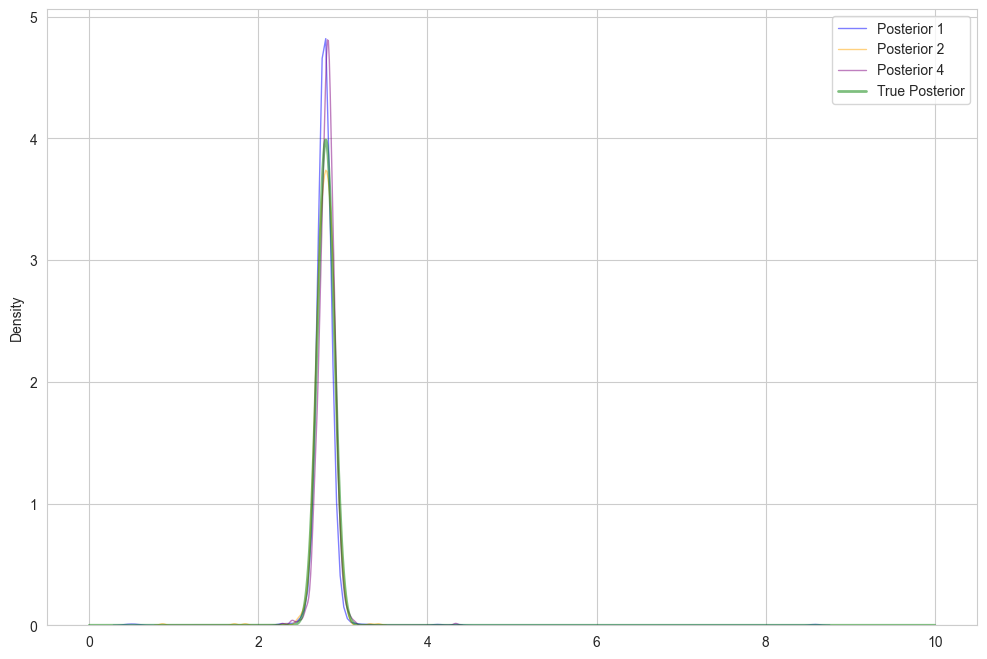

In [ ]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(posterior_1[:, 0], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(posterior_2[:, 0], label='Posterior 2', color='orange', linewidth=1, alpha=0.5)
sns.kdeplot(posterior_3[:, 0], label='Posterior 3', color='red', linewidth=1, alpha=0.5)
sns.kdeplot(posterior_4[:, 0], label='Posterior 4', color='purple', linewidth=1, alpha=0.5)
plt.plot(theta_grid, posterior, label='True Posterior', color='green', linewidth=2, alpha=0.5)
plt.legend()